<a href="https://colab.research.google.com/github/Shre20-create/Anomaly-Detection-Credit-Card-Fraud-Detection-/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Load & Explore Data

In [ ]:
import pandas as pd

df = pd.read_csv("/content/creditcard.csv")
print(df.head())
print(df['Class'].value_counts(normalize=True))


   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

2. Data Preprocessing

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


3. Autoencoder for Anomaly Detection

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

input_dim = X_train.shape[1]
encoding_dim = 14  # Compression level

autoencoder = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(encoding_dim, activation='relu'),
    layers.Dense(7, activation='relu'),
    layers.Dense(encoding_dim, activation='relu'),
    layers.Dense(input_dim, activation='sigmoid')
])

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

# Train only on normal transactions
X_train_norm = X_train[y_train == 0]
autoencoder.fit(X_train_norm, X_train_norm, epochs=20, batch_size=256, shuffle=True, validation_split=0.2)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           434 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 14)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 30)             │           450 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,101 (4.30 KB)

 Trainable params: 1,101 (4.30 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1.0520 - val_loss: 0.8722
Epoch 2/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8800 - val_loss: 0.8431
Epoch 3/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.8592 - val_loss: 0.8339
Epoch 4/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8293 - val_loss: 0.8270
Epoch 5/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8394 - val_loss: 0.8230
Epoch 6/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8124 - val_loss: 0.8204
Epoch 7/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8238 - val_loss: 0.8177
Epoch 8/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8336 - val_loss: 0.8159
Epoch 9/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8139 - val_loss: 0.8146
Epoch 10/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.8389 - val_loss: 0.8133
Epoch 11/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.8361 - val_loss: 0.8128
Epoch 12/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

4. Reconstruction Error for Anomaly Detection

In [ ]:
import numpy as np

reconstructions = autoencoder.predict(X_test)
mse = np.mean(np.power(X_test - reconstructions, 2), axis=1)
threshold = np.percentile(mse, 95)  # e.g., 95th percentile of normal samples
y_pred_auto = (mse > threshold).astype(int)


1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 987us/step


5. Isolation Forest Approach

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

iso = IsolationForest(contamination=0.001, random_state=42)
y_pred_iso = iso.fit_predict(X_test)
y_pred_iso = [1 if x == -1 else 0 for x in y_pred_iso]


6. Evaluation

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Autoencoder Results:")
print(classification_report(y_test, y_pred_auto))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_auto))

print("\nIsolation Forest Results:")
print(classification_report(y_test, y_pred_iso))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_iso))


Autoencoder Results:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     56864
           1       0.03      0.86      0.06        98

    accuracy                           0.95     56962
   macro avg       0.51      0.90      0.52     56962
weighted avg       1.00      0.95      0.97     56962

ROC-AUC: 0.9042590340863413

Isolation Forest Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.27      0.15      0.19        98

    accuracy                           1.00     56962
   macro avg       0.63      0.58      0.60     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.5761701029595856


7. Visual Insights

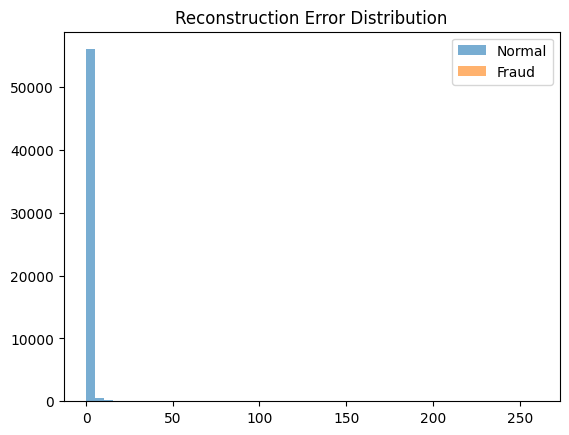

In [ ]:
import matplotlib.pyplot as plt

plt.hist(mse[y_test == 0], bins=50, alpha=0.6, label='Normal')
plt.hist(mse[y_test == 1], bins=50, alpha=0.6, label='Fraud')
plt.legend()
plt.title('Reconstruction Error Distribution')
plt.show()
